# Numerical experiments

Reusable annealing logic lives in `functions/` and `helpers/`. This notebook only sets parameters, runs experiments

In [33]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from functions.annealing import (
    empirical_fixed_temperature_distribution,
    empirical_relative_entropy,
    fixed_temperature_ensemble,
    simulated_annealing,
    trace_simulated_annealing,
)
from functions.plotting import plot_optimization_result


def objective(x):
    return x**(2) + 10* np.sin(x) ** 2

## Simulated annealing optimizer

Simple optimizer
Best point: 8.809210187710192e-05
Best objective value: 8.536240234364611e-08

Traced optimizer
Best point: 8.809210187710192e-05
Best objective value: 8.536240234364611e-08


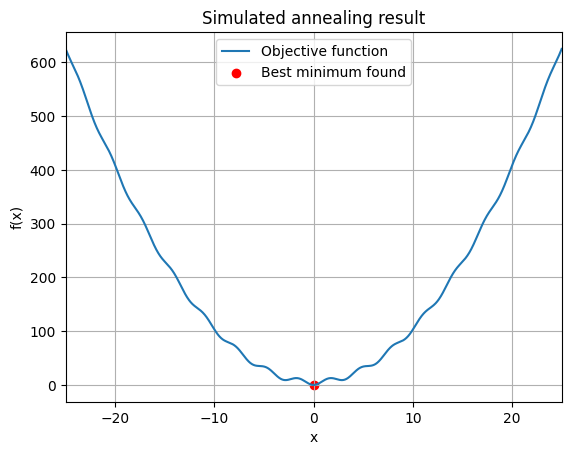

In [34]:
t0 = 100.0
n_iter = 20000
x0 = 20.0
seed = 762

best_x, best_value = simulated_annealing(objective, x0, t0, n_iter, seed)

best_x_trace, best_value_trace, trajectory, temperatures = trace_simulated_annealing(
    objective, x0, t0, n_iter, seed
)

print("Simple optimizer")
print("Best point:", best_x)
print("Best objective value:", best_value)

print("\nTraced optimizer")
print("Best point:", best_x_trace)
print("Best objective value:", best_value_trace)

x_min = -25.0
x_max = 25.0

fig, ax = plot_optimization_result(
    objective,
    best_x_trace,
    best_value_trace,
    x_min=x_min,
    x_max=x_max,
    show=False,
)

## Boltzmann-Gibbs empirical distribution

Estimate the distribution for a fixed temperature at long time by running many independent runs from the same initial point.


Boltzmann-Gibbs estimate at fixed temperature and long time
Initial cooling steps: 5
Fixed temperature: 51.38983423697507
Independent runs: 10000
Stopping iteration: 1000
Sample mean: -0.021315431240516335
Sample standard deviation: 5.095053455608083


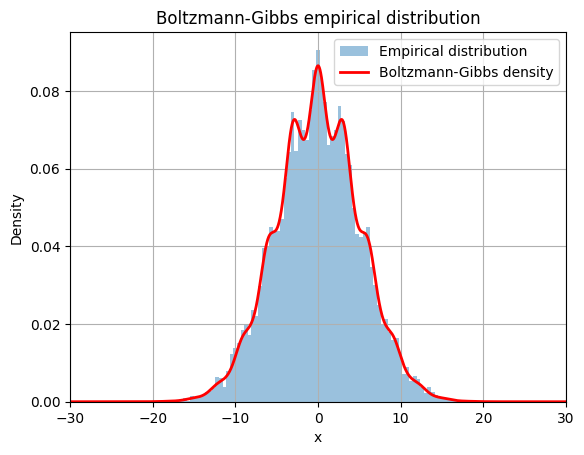

In [ ]:
t0 = 100.0
n_initial_cooling_steps = 5
total_runs = 10000
stopping_iteration = 1000
x0 = 20.0
seed = 762

samples, fixed_temp = empirical_fixed_temperature_distribution(
    fun=objective,
    x0=x0,
    t0=t0,
    n_initial_cooling_steps=n_initial_cooling_steps,
    total_runs=total_runs,
    stopping_iteration=stopping_iteration,
    seed=seed,
)

x_min = -30.0
x_max = 30.0
x_grid = np.linspace(x_min, x_max, 5_000)
bg_density = np.exp(-objective(x_grid) / fixed_temp)
bg_density = bg_density / np.trapezoid(bg_density, x_grid)

fig, ax = plt.subplots()
ax.hist(samples, bins=80, density=True, alpha=0.45, label="Empirical distribution")
ax.plot(x_grid, bg_density, color="red", linewidth=2, label="Boltzmann-Gibbs density")
ax.set_xlim(x_min, x_max)
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Boltzmann-Gibbs empirical distribution")
ax.legend()
ax.grid(True)

print("Boltzmann-Gibbs estimate at fixed temperature and long time")
print("Initial cooling steps:", n_initial_cooling_steps)
print("Fixed temperature:", fixed_temp)
print("Independent runs:", total_runs)
print("Stopping iteration:", stopping_iteration)
print("Sample mean:", samples.mean())
print("Sample standard deviation:", samples.std())

## Fixed-temperature entropy decay

Fix $T$ and evolve many independent Metropolis trajectories from the same initial point. At each observation time, estimate the density and the coarse-grained relative entropy

$$H(f_t\mid f_{\mathcal{F}}^{\infty}) = \sum_i p_i(t)\log\frac{p_i(t)}{q_i},$$

where $p_i(t)$ and $q_i$ are the empirical and Boltzmann--Gibbs probabilities in histogram bin $i$. The finite ensemble produces a small sampling floor, so the estimated entropy is not expected to be exactly zero or strictly monotone at late times.

Initial relative entropy: 704.017
Final relative entropy:   2.87728


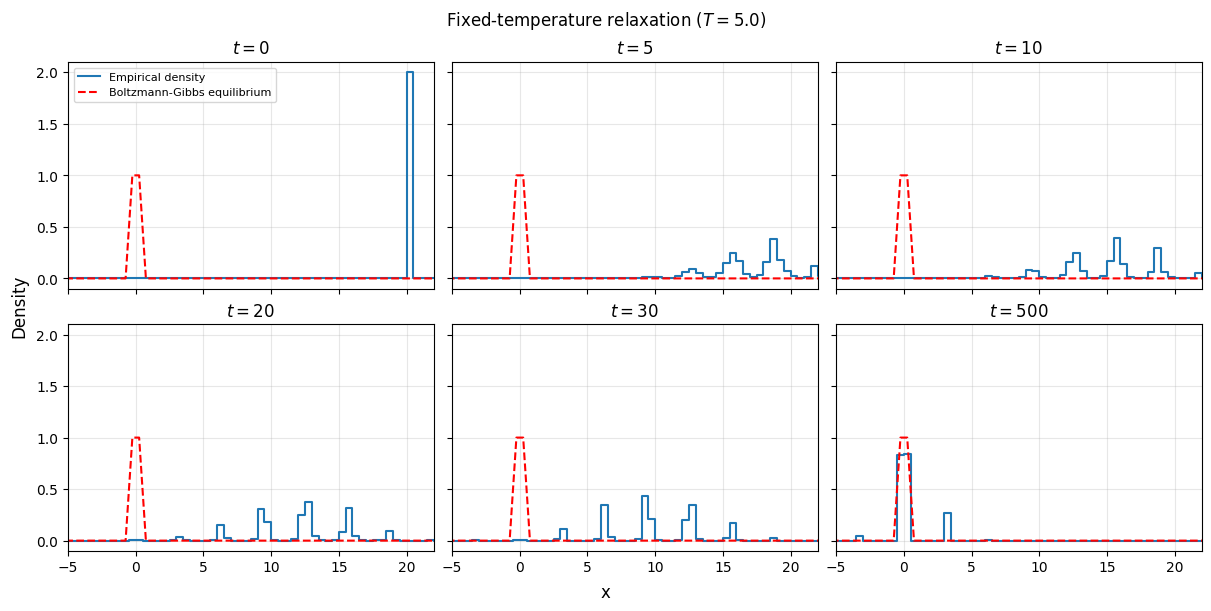

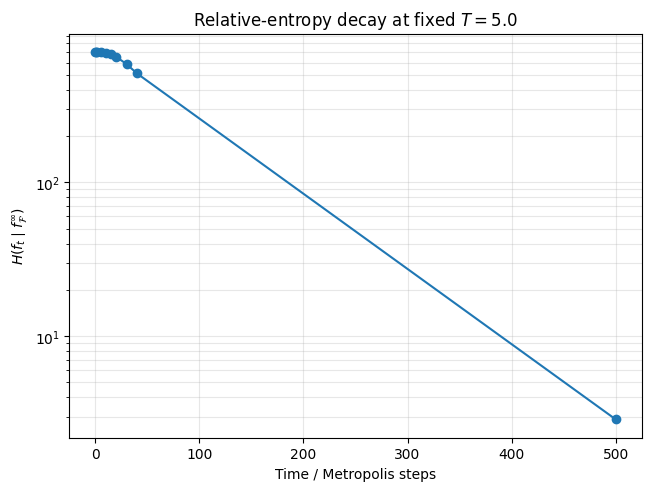

In [32]:
temperature = 5.0
x0 = 20.0
total_runs = 10_000
observation_times = [0, 1, 2, 5, 10, 15, 20, 30, 40, 500]
seed = 762

times, ensemble_samples = fixed_temperature_ensemble(
    fun=objective,
    x0=x0,
    temperature=temperature,
    observation_times=observation_times,
    total_runs=total_runs,
    seed=seed,
)

bin_edges = np.linspace(-35.0, 35.0, 141)
bin_centers, empirical_densities, equilibrium_density, relative_entropy = (
    empirical_relative_entropy(ensemble_samples, objective, temperature, bin_edges)
)

density_times = np.array([0, 5, 10, 20, 30, 500])
density_indices = np.searchsorted(times, density_times)

fig_density, axes = plt.subplots(
    2, 3, figsize=(12, 6), sharex=True, sharey=True, constrained_layout=True
)
for ax, time, density in zip(
    axes.flat, density_times, empirical_densities[density_indices]
):
    ax.step(bin_centers, density, where="mid", label="Empirical density")
    ax.plot(
        bin_centers,
        equilibrium_density,
        color="red",
        linestyle="--",
        label="Boltzmann-Gibbs equilibrium",
    )
    ax.set_xlim(-5.0, 22.0)
    ax.set_title(rf"$t={time}$")
    ax.grid(True, alpha=0.3)

axes.flat[0].legend(fontsize=8)
fig_density.supxlabel("x")
fig_density.supylabel("Density")
fig_density.suptitle(rf"Fixed-temperature relaxation ($T={temperature}$)")

fig_entropy, ax = plt.subplots(constrained_layout=True)
ax.semilogy(times, relative_entropy, marker="o")
ax.set_xlabel("Time / Metropolis steps")
ax.set_ylabel(r"$H(f_t\mid f_{\mathcal{F}}^{\infty})$")
ax.set_title(rf"Relative-entropy decay at fixed $T={temperature}$")
ax.grid(True, which="both", alpha=0.3)

figure_dir = Path("figures")
figure_dir.mkdir(exist_ok=True)
fig_density.savefig(figure_dir / "fixed_temperature_densities.pdf")
fig_entropy.savefig(figure_dir / "relative_entropy_decay.pdf")

print(f"Initial relative entropy: {relative_entropy[0]:.6g}")
print(f"Final relative entropy:   {relative_entropy[-1]:.6g}")
plt.show()